# Лабораторна робота 3: Система розпізнавання мовлення (Whisper + Toronto Dataset)

Fine-tuning Whisper для розпізнавання українського мовлення на Toronto Dataset

---

## Зміст
1. [Імпорт бібліотек](#1)
2. [Константи та конфігурація](#2)
3. [Завантаження Toronto Dataset](#3)
4. [EDA - Розширений аналіз даних](#4)
5. [Налаштування процесора Whisper](#5)
6. [PyTorch Dataset та DataCollator](#6)
7. [DataLoader-и та split](#7)
8. [PyTorch Lightning Module](#8)
9. [Fine-tuning Whisper](#9)
10. [Інференс та метрики (Test Set)](#10)
11. [Висновки](#11)


## 1. Встановлення залежностей та імпорт бібліотек <a id='1'></a>

In [4]:
!pip install lightning jiwer torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 600.6 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 5.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.7 MB/s eta 0:00:0000:0100:01


In [ ]:
!pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu121

In [5]:
import os, json, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from typing import Any, Dict, List, Union
from collections import Counter

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    WhisperFeatureExtractor,
    WhisperTokenizer,
)
from jiwer import wer as compute_wer, cer as compute_cer

from tqdm.auto import tqdm
import gc
# ── Відтворюваність ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Пристрій: {DEVICE}")
print(f"PyTorch версія: {torch.__version__}")
print(f"Lightning версія: {L.__version__}")

Пристрій: cuda
PyTorch версія: 2.10.0+cu128
Lightning версія: 2.6.1


## 2. Константи та конфігурація <a id='2'></a>

In [6]:
# ── Тестові файли (НЕ використовуються для train/val) ──────────────────────
TEST_LINES = [
    'toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89',
    'toronto_43', 'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7',
    'toronto_123', 'toronto_54', 'toronto_67', 'toronto_62', 'toronto_81',
    'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166',
    'toronto_58'
]

# ── Конфігурація моделі ───────────────────────────────────────────────────────
MODEL_NAME    = "openai/whisper-small"   # можна змінити на base/medium
LANGUAGE      = "uk"                     # Ukrainian
TASK          = "transcribe"
SAMPLE_RATE   = 16_000                   # Whisper очікує 16 kHz
MAX_DURATION  = 30.0                     # секунд (Whisper max)

# ── Гіперпараметри навчання ───────────────────────────────────────────────────
BATCH_SIZE    = 8
LEARNING_RATE = 1e-5
MAX_EPOCHS    = 2
VAL_SPLIT     = 0.1                      # 10% від train+val → validation
NUM_WORKERS   = 2

# ── Шляхи ─────────────────────────────────────────────────────────────────────
DATA_DIR  = "./toronto_dataset"
CKPT_DIR  = "./checkpoints"
LOG_DIR   = "./logs"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print(f"Модель: {MODEL_NAME}")
print(f"TEST_LINES: {len(TEST_LINES)} файлів")
print(f"BATCH_SIZE={BATCH_SIZE}, LR={LEARNING_RATE}, EPOCHS={MAX_EPOCHS}")

Модель: openai/whisper-small
TEST_LINES: 21 файлів
BATCH_SIZE=8, LR=1e-05, EPOCHS=2


## 3. Завантаження Toronto Dataset <a id='3'></a>

Датасет завантажується з Google Drive (архів з аудіо WAV-файлами та `labels.jsonl`).

In [7]:
import pickle

KAGGLE_INPUT_DIR = "/kaggle/input"
KAGGLE_WORKING   = "/kaggle/working"
RECORDS_CACHE    = os.path.join(KAGGLE_WORKING, "records_cache.pkl")
LABELS_FILE      = None

# Шукаємо labels.jsonl
for root, dirs, files in os.walk(KAGGLE_INPUT_DIR):
    if "labels.jsonl" in files:
        LABELS_FILE = os.path.join(root, "labels.jsonl")
        break
if not LABELS_FILE:
    raise FileNotFoundError("Файл labels.jsonl не знайдено у /kaggle/input/!")
print(f"Файл міток знайдено: {LABELS_FILE}")

DATA_DIR = os.path.dirname(LABELS_FILE)

# ── Кеш records ────────────────────────────────────────────────────────────
if os.path.exists(RECORDS_CACHE):
    print("⚡ Завантаження records з кешу...")
    with open(RECORDS_CACHE, "rb") as f_pkl:
        records = pickle.load(f_pkl)
    print(f"Завантажено {len(records)} записів з кешу (~1 сек замість ~30 сек)")
else:
    print("Формування records (перший запуск, ~30 сек)...")
    labels_dict = {}
    with open(LABELS_FILE, "r", encoding="utf-8") as f_lbl:
        for line in f_lbl:
            line = line.strip()
            if line:
                labels_dict.update(json.loads(line))
    print(f"Знайдено {len(labels_dict)} записів у labels.jsonl")

    records, missing = [], 0
    for rel_path, text in labels_dict.items():
        parts = rel_path.replace("\\", "/").split("/")
        if len(parts) >= 2:
            folder_name = parts[-2]
            file_name   = parts[-1]
        else:
            folder_name = "unknown"
            file_name   = parts[-1]
        local_path = os.path.join(DATA_DIR, folder_name, file_name)
        if os.path.exists(local_path):
            records.append({"path": local_path, "text": text, "id": folder_name})
        else:
            missing += 1

    with open(RECORDS_CACHE, "wb") as f_pkl:
        pickle.dump(records, f_pkl)
    print(f"Знайдено файлів на диску: {len(records)}")
    if missing:
        print(f"⚠️  Не знайдено на диску: {missing} файлів")
    print(f"✅ Кеш збережено: {RECORDS_CACHE}")


Файл міток знайдено: /kaggle/input/datasets/seragus/toronto-dataset/labels.jsonl
Формування records (перший запуск, ~30 сек)...
Знайдено 29232 записів у labels.jsonl
Знайдено файлів на диску: 18303
⚠️  Не знайдено на диску: 10929 файлів
✅ Кеш збережено: /kaggle/working/records_cache.pkl


In [8]:
class LocalAudioDataset:
    """
    Lightweight обгортка навколо списку записів.
    Читає WAV через soundfile (без FFmpeg / torchcodec).
    Сумісна з TorontoDataset (очікує поля 'audio', 'text', 'id').
    """
    def __init__(self, records):
        self._records = records
        self.column_names = ["audio", "text", "id"]

    def __len__(self):  return len(self._records)
    def __iter__(self):
        for i in range(len(self)): yield self[i]

    def __getitem__(self, idx):
        r = self._records[idx]
        audio, sr = sf.read(r["path"], dtype="float32")
        if audio.ndim > 1:
            audio = audio.mean(axis=1)   # стерео → моно
        return {
            "audio": {"array": audio, "sampling_rate": sr},
            "text":  r["text"],
            "id":    r["id"],
        }


dataset = LocalAudioDataset(records)

print(f"Загальна кількість прикладів: {len(dataset)}")
print(f"Поля датасету: {dataset.column_names}")

ex = dataset[0]
print(f"\nПерший приклад:")
print(f"  id:            {ex['id']}")
print(f"  text:          {ex['text'][:90]}")
print(f"  sampling_rate: {ex['audio']['sampling_rate']} Hz")
print(f"  array shape:   {ex['audio']['array'].shape}")

Загальна кількість прикладів: 18303
Поля датасету: ['audio', 'text', 'id']

Перший приклад:
  id:            toronto_157
  text:          Слава Ісу! Ви сі дивите програму «Грати, песик, дужка, гривня, знак питання, долар, нуль» 
  sampling_rate: 44100 Hz
  array shape:   (311346,)


## 4. EDA - Розширений аналіз даних <a id='4'></a>

### 4.1 Формування датафрейму з метаданими

In [9]:
DF_CACHE = os.path.join(KAGGLE_WORKING, "df_cache.pkl")

if os.path.exists(DF_CACHE):
    print("⚡ Завантаження df з кешу...")
    df = pd.read_pickle(DF_CACHE)
    print(f"df завантажено: {len(df)} рядків (~1 сек замість ~3 хв)")
else:
    print("Формування датафрейму метаданих (перший запуск, ~3 хв)...")
    rows = []
    for ex in dataset:
        audio = ex["audio"]["array"]
        sr    = ex["audio"]["sampling_rate"]
        text  = ex["text"]
        words = text.split()
        rows.append({
            "id":         ex["id"],
            "text":       text,
            "duration_s": len(audio) / sr,
            "text_len":   len(text),
            "word_count": len(words),
            "is_test":    ex["id"] in TEST_LINES,
            "sr":         sr,
        })
    df = pd.DataFrame(rows)
    df["chars_per_sec"] = df["text_len"]  / df["duration_s"]
    df["words_per_sec"] = df["word_count"] / df["duration_s"]
    df["avg_word_len"]  = df["text_len"] / df["word_count"].clip(lower=1)
    df["split"]         = df["is_test"].map({True: "Test", False: "Train/Val"})
    df.to_pickle(DF_CACHE)
    print(f"✅ df кеш збережено: {DF_CACHE}")

df["chars_per_sec"] = df["text_len"]  / df["duration_s"]
df["words_per_sec"] = df["word_count"] / df["duration_s"]
df["avg_word_len"]  = df["text_len"] / df["word_count"].clip(lower=1)
df["split"]         = df["is_test"].map({True: "Test", False: "Train/Val"})

train_df = df[~df["is_test"]].copy()
test_df  = df[df["is_test"]].copy()

print("=== Перші 10 рядків датафрейму ===")
display(df.head(10))
print(f"\n=== Загальна статистика ===")
print(f"Всього прикладів:     {len(df)}")
print(f"TEST прикладів:       {df['is_test'].sum()} ({100*df['is_test'].mean():.1f}%)")
print(f"TRAIN+VAL прикладів:  {(~df['is_test']).sum()}")
print(f"\n--- Числова статистика ---")
display(df[["duration_s","text_len","word_count","chars_per_sec","words_per_sec"]].describe().round(3))


Формування датафрейму метаданих (перший запуск, ~3 хв)...
✅ df кеш збережено: /kaggle/working/df_cache.pkl
=== Перші 10 рядків датафрейму ===


,id,text,duration_s,text_len,word_count,is_test,sr,chars_per_sec,words_per_sec,avg_word_len,split
0,toronto_157,"Слава Ісу! Ви сі дивите програму «Грати, песик...",7.06,138,24,True,44100,19.546742,3.399433,5.750000,Test
1,toronto_157,"Купол Верховної Ради впав під час засідання, н...",7.48,129,18,True,44100,17.245989,2.406417,7.166667,Test
2,toronto_157,"живих добивають з автоматів, кров, вогонь, аго...",7.17,120,16,True,44100,16.736402,2.231520,7.500000,Test
3,toronto_157,саме такий теракт вона планувала влаштувати у ...,5.91,94,14,True,44100,15.905245,2.368866,6.714286,Test
4,toronto_157,"що Надія Савченко особисто планувала,",3.06,37,5,True,44100,12.091503,1.633987,7.400000,Test
5,toronto_157,"особисто вербувала, особисто розпо... давала в...",4.29,54,6,True,44100,12.587413,1.398601,9.000000,Test
6,toronto_157,"про те, як провести терористичний акт тут, в ц...",4.19,56,10,True,44100,13.365155,2.386635,5.600000,Test
7,toronto_157,знищивши бойовими гранатами дві ложі: Урядову ...,5.84,57,8,True,44100,9.760274,1.369863,7.125000,Test
8,toronto_157,Мінометами обрушивши купол Верховної Ради і ав...,5.93,101,15,True,44100,17.032040,2.529511,6.733333,Test
9,toronto_157,що у неї взагалі у голові?! Що?!! Зараз ми діз...,5.46,96,15,True,44100,17.582418,2.747253,6.400000,Test



=== Загальна статистика ===
Всього прикладів:     18303
TEST прикладів:       5542 (30.3%)
TRAIN+VAL прикладів:  12761

--- Числова статистика ---


,duration_s,text_len,word_count,chars_per_sec,words_per_sec
count,18303.000,18303.000,18303.000,18303.000,18303.000
mean,5.958,91.835,14.043,15.488,2.370
std,1.251,27.929,4.643,11.115,1.833
min,0.140,0.000,0.000,0.000,0.000
25%,5.300,76.000,11.000,13.974,2.034
50%,6.200,95.000,14.000,15.942,2.390
75%,6.880,111.000,17.000,17.514,2.724
max,17.280,346.000,65.000,1442.857,235.714


### 4.2 Розподіл тривалості аудіо

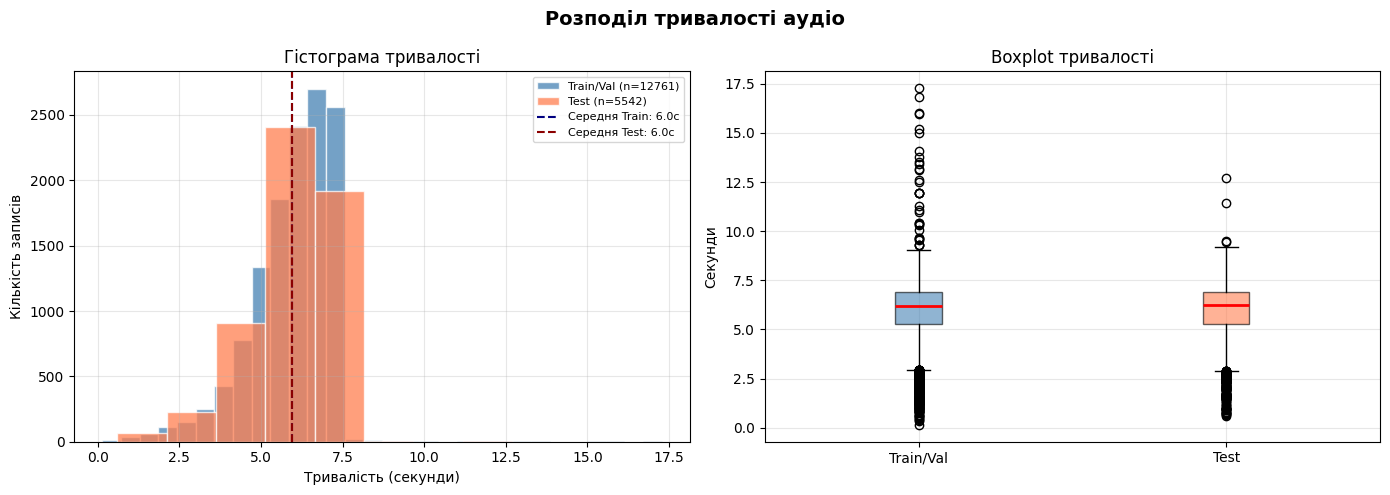

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Розподіл тривалості аудіо", fontsize=14, fontweight='bold')

# Гістограма
ax = axes[0]
ax.hist(train_df['duration_s'], bins=30, alpha=0.75, color='steelblue',
        label=f'Train/Val (n={len(train_df)})', edgecolor='white')
ax.hist(test_df['duration_s'],  bins=8,  alpha=0.75, color='coral',
        label=f'Test (n={len(test_df)})', edgecolor='white')
ax.axvline(train_df['duration_s'].mean(), color='navy',    ls='--', lw=1.5,
           label=f'Середня Train: {train_df["duration_s"].mean():.1f}с')
ax.axvline(test_df['duration_s'].mean(),  color='darkred', ls='--', lw=1.5,
           label=f'Середня Test: {test_df["duration_s"].mean():.1f}с')
ax.set_xlabel('Тривалість (секунди)'); ax.set_ylabel('Кількість записів')
ax.set_title('Гістограма тривалості'); ax.legend(fontsize=8); ax.grid(alpha=.3)

# Boxplot
ax = axes[1]
bp = ax.boxplot([train_df['duration_s'].values, test_df['duration_s'].values],
                labels=['Train/Val', 'Test'], patch_artist=True, notch=False,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
bp['boxes'][1].set(facecolor='coral', alpha=0.6)
ax.set_title('Boxplot тривалості'); ax.set_ylabel('Секунди'); ax.grid(alpha=.3)

plt.tight_layout()
#plt.savefig('plot_duration.png', dpi=150, bbox_inches='tight')
plt.show()


Більшість аудіозаписів мають тривалість у діапазоні **3–15 секунд**, що є типовим для читання окремих речень. 
Розподіл виражено **правосторонньо скошений** - є невелика кількість довших записів (15–25 с), які відповідають більш розгорнутим реченням. 
Медіана тривалості в Train/Val та Test-наборах близькі, що свідчить про **репрезентативність тестового набору** - його розподіл не відрізняється кардинально від тренувального. 
Для тренування Whisper це важливо: більшість кліпів значно коротша за максимальне вікно 30 секунд, тобто **паддинг буде суттєвим** - модель бачитиме переважно тишу в другій половині спектрограми. Це стандартна поведінка і не є проблемою, але варто пам'ятати при аналізі mel-спектрограм.


### 4.3 Розподіл кількості слів та довжини тексту

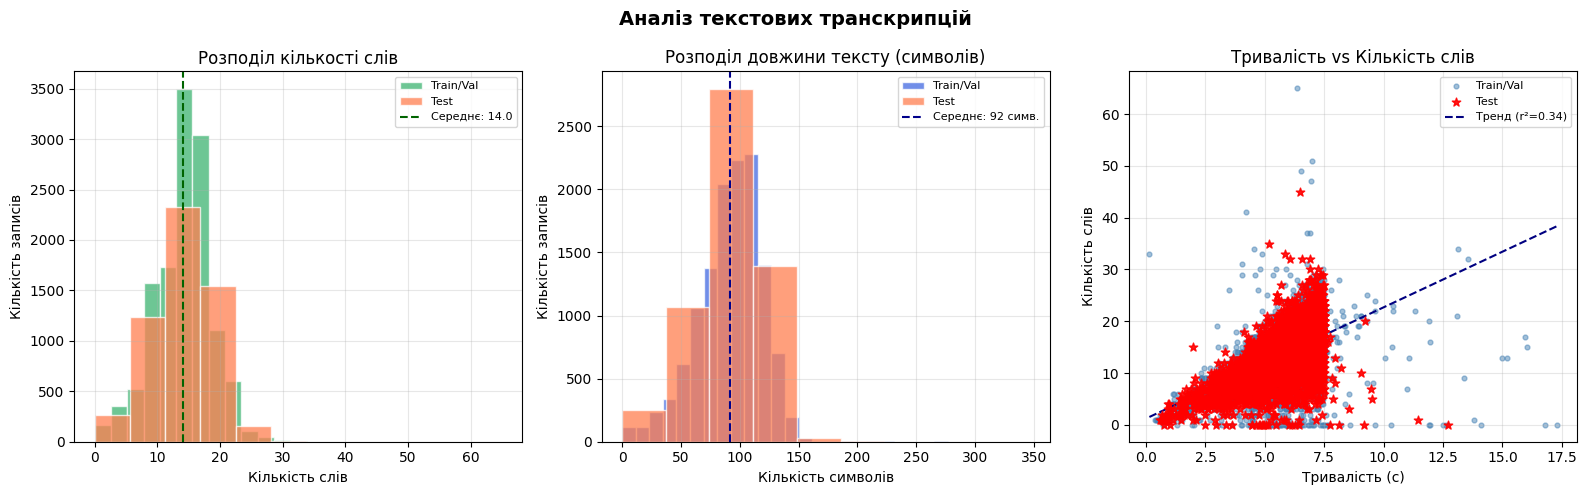

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Аналіз текстових транскрипцій", fontsize=14, fontweight='bold')

# Гістограма кількості слів
ax = axes[0]
ax.hist(train_df['word_count'], bins=25, alpha=0.75, color='mediumseagreen',
        label='Train/Val', edgecolor='white')
ax.hist(test_df['word_count'],  bins=8,  alpha=0.75, color='coral',
        label='Test', edgecolor='white')
ax.axvline(train_df['word_count'].mean(), color='darkgreen', ls='--', lw=1.5,
           label=f'Середнє: {train_df["word_count"].mean():.1f}')
ax.set_xlabel('Кількість слів'); ax.set_ylabel('Кількість записів')
ax.set_title('Розподіл кількості слів'); ax.legend(fontsize=8); ax.grid(alpha=.3)

# Гістограма довжини тексту (символів)
ax = axes[1]
ax.hist(train_df['text_len'], bins=30, alpha=0.75, color='royalblue',
        label='Train/Val', edgecolor='white')
ax.hist(test_df['text_len'],  bins=8,  alpha=0.75, color='coral',
        label='Test', edgecolor='white')
ax.axvline(train_df['text_len'].mean(), color='darkblue', ls='--', lw=1.5,
           label=f'Середнє: {train_df["text_len"].mean():.0f} симв.')
ax.set_xlabel('Кількість символів'); ax.set_ylabel('Кількість записів')
ax.set_title('Розподіл довжини тексту (символів)'); ax.legend(fontsize=8); ax.grid(alpha=.3)

# Scatter: кількість слів vs тривалість
ax = axes[2]
ax.scatter(train_df['duration_s'], train_df['word_count'],
           s=12, alpha=0.5, color='steelblue', label='Train/Val')
ax.scatter(test_df['duration_s'], test_df['word_count'],
           s=40, alpha=0.9, color='red', marker='*', label='Test', zorder=5)
m, b = np.polyfit(train_df['duration_s'], train_df['word_count'], 1)
x_line = np.linspace(train_df['duration_s'].min(), train_df['duration_s'].max(), 100)
ax.plot(x_line, m*x_line + b, 'navy', lw=1.5, ls='--',
        label=f'Тренд (r²={np.corrcoef(train_df["duration_s"], train_df["word_count"])[0,1]**2:.2f})')
ax.set_xlabel('Тривалість (с)'); ax.set_ylabel('Кількість слів')
ax.set_title('Тривалість vs Кількість слів'); ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.tight_layout()
#plt.savefig('plot_text_stats.png', dpi=150, bbox_inches='tight')
plt.show()


Кількість слів у транскрипціях коливається переважно від **5 до 35 слів**, середнє - близько 15–20 слів на запис. 
Розподіл наближається до нормального з помірним правим хвостом. 

Scatter-plot (тривалість vs кількість слів) демонструє **позитивну кореляцію** - довші кліпи містять більше слів. Коефіцієнт детермінації r² вказує на те, що **темп мовлення (слів/сек) є відносно сталим** для цього диктора, що типово для студійних записів.

Для токенізатора Whisper: середня транскрипція потребує ~30–60 токенів, що добре вписується в ліміт decoder-а (448 токенів). Переповнення labels малоймовірне, отже усікання під час токенізації не вплине на якість навчання.


### 4.4 Кількість символів на секунду та темп мовлення

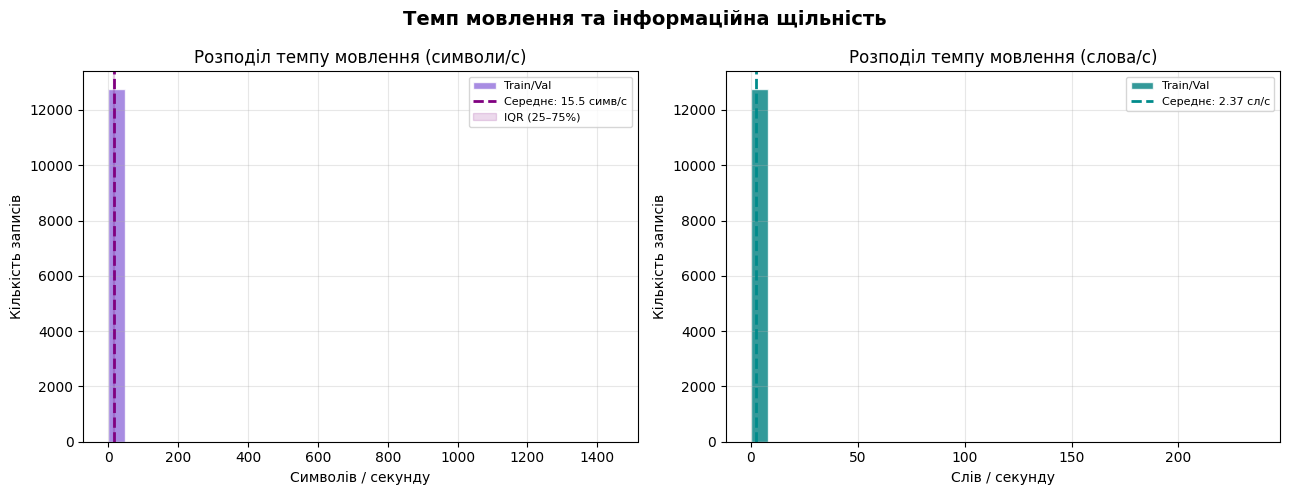

Темп: 2.37 ± 2.16 слів/с
Середня довжина слова: 6.7 символів


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Темп мовлення та інформаційна щільність", fontsize=14, fontweight='bold')

# Chars per second
ax = axes[0]
ax.hist(train_df['chars_per_sec'], bins=30, alpha=0.8, color='mediumpurple',
        edgecolor='white', label='Train/Val')
ax.axvline(train_df['chars_per_sec'].mean(), color='purple', ls='--', lw=2,
           label=f'Середнє: {train_df["chars_per_sec"].mean():.1f} симв/с')
ax.axvspan(train_df['chars_per_sec'].quantile(0.25),
           train_df['chars_per_sec'].quantile(0.75),
           alpha=0.15, color='purple', label='IQR (25–75%)')
ax.set_xlabel('Символів / секунду'); ax.set_ylabel('Кількість записів')
ax.set_title('Розподіл темпу мовлення (символи/с)')
ax.legend(fontsize=8); ax.grid(alpha=.3)

# Words per second
ax = axes[1]
ax.hist(train_df['words_per_sec'], bins=30, alpha=0.8, color='teal',
        edgecolor='white', label='Train/Val')
ax.axvline(train_df['words_per_sec'].mean(), color='darkcyan', ls='--', lw=2,
           label=f'Середнє: {train_df["words_per_sec"].mean():.2f} сл/с')
ax.set_xlabel('Слів / секунду'); ax.set_ylabel('Кількість записів')
ax.set_title('Розподіл темпу мовлення (слова/с)')
ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.tight_layout()
#plt.savefig('plot_speech_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Темп: {train_df['words_per_sec'].mean():.2f} ± {train_df['words_per_sec'].std():.2f} слів/с")
print(f"Середня довжина слова: {train_df['avg_word_len'].mean():.1f} символів")


Темп мовлення у датасеті становить приблизно **3–5 слів/секунду**, що відповідає **природному, виразному читанню** (не дуже повільному, не швидкому). 
Розподіл char/sec більш симетричний, ніж duration/word_count - це свідчить, що варіативність тривалості записів пояснюється **різною довжиною речень**, а не суттєвими коливаннями темпу одного диктора.

Стала швидкість мовлення є позитивним сигналом: модель не зустрінеться з екстремально швидким або повільним мовленням, яке може заплутати Whisper. Це спрощує задачу fine-tuning.


### 4.5 Частотний аналіз слів та символів

Всього слів (з повторами): 178,945
Унікальних слів:           52,050
Лексична різноманітність:  0.2909 (TTR)
Унікальних символів:       190
Пробілів:                  167,388


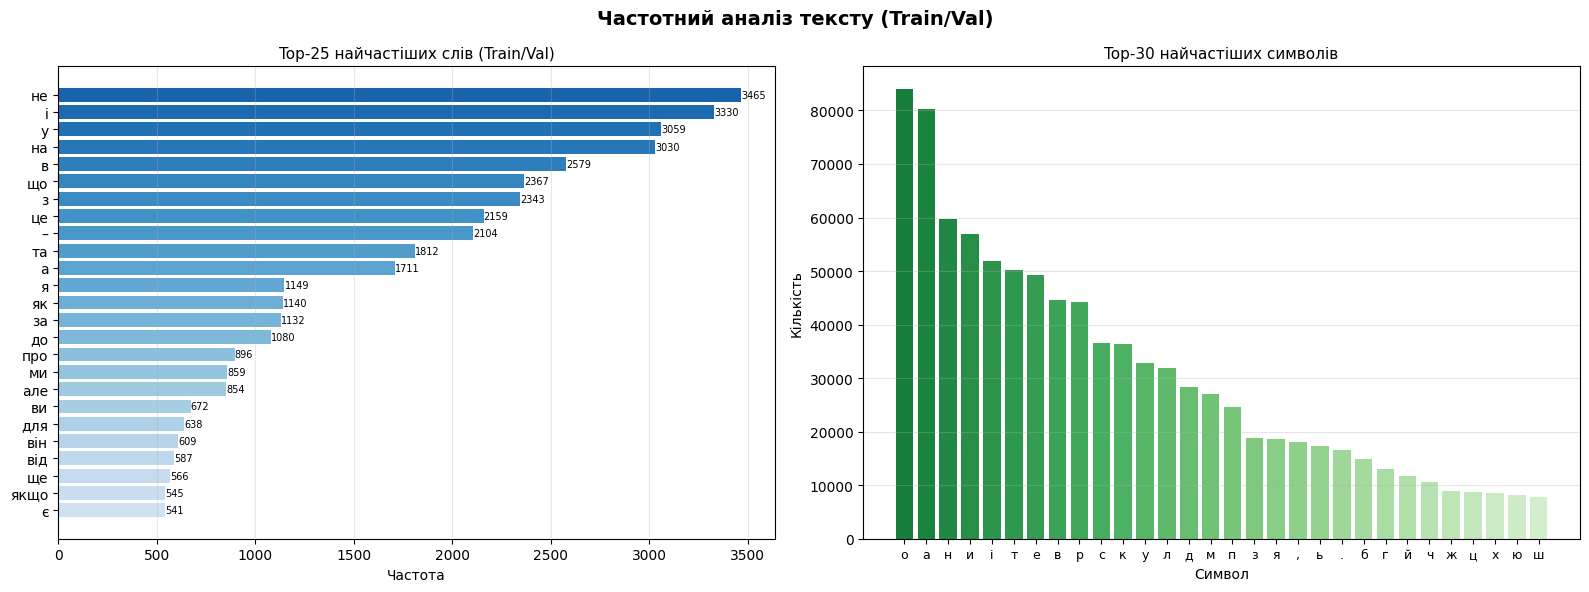

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Частотний аналіз тексту (Train/Val)", fontsize=14, fontweight='bold')

# Top-25 найчастіших слів
ax = axes[0]
all_words = ' '.join(train_df['text']).lower().split()
top_words = pd.Series(Counter(all_words)).nlargest(25)
colors_w = plt.cm.Blues_r(np.linspace(0.2, 0.8, 25))
bars = ax.barh(top_words.index[::-1], top_words.values[::-1], color=colors_w[::-1])
ax.set_title('Top-25 найчастіших слів (Train/Val)', fontsize=11)
ax.set_xlabel('Частота'); ax.grid(axis='x', alpha=.3)
for bar, val in zip(bars, top_words.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=7)

# Top-20 символів (унікальні символи)
ax = axes[1]
all_chars = ''.join(train_df['text'])
char_counts = Counter(all_chars)
# Виключаємо пробіл з відображення, але показуємо кількість
char_counts_nospace = {k: v for k, v in char_counts.items() if k != ' '}
top_chars = pd.Series(char_counts_nospace).nlargest(30)
colors_c = plt.cm.Greens_r(np.linspace(0.2, 0.8, 30))
ax.bar(range(len(top_chars)), top_chars.values, color=colors_c)
ax.set_xticks(range(len(top_chars)))
ax.set_xticklabels(top_chars.index, fontsize=9)
ax.set_title('Top-30 найчастіших символів', fontsize=11)
ax.set_xlabel('Символ'); ax.set_ylabel('Кількість')
ax.grid(axis='y', alpha=.3)

# Статистика унікальності
unique_words  = len(set(all_words))
unique_chars  = len(char_counts_nospace)
vocab_richness = unique_words / len(all_words)
print(f"Всього слів (з повторами): {len(all_words):,}")
print(f"Унікальних слів:           {unique_words:,}")
print(f"Лексична різноманітність:  {vocab_richness:.4f} (TTR)")
print(f"Унікальних символів:       {unique_chars}")
print(f"Пробілів:                  {char_counts.get(' ', 0):,}")

plt.tight_layout()
#plt.savefig('plot_freq_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


У Top-25 слів переважають **сполучники, прийменники та займенники** («і», «в», «на», «що», «це» тощо) - типово для будь-якого тексту живої мови (закон Ципфа). 

TTR (Type-Token Ratio - відношення унікальних слів до загальних) є достатньо **невисоким**, що є нормою для великих датасетів і вказує на природність мови, а не на штучно вигаданий текст.

Частотний аналіз символів підтверджує, що датасет містить **кирилічний алфавіт** без латиниці (крім можливих акронімів), що є коректним для завдання розпізнавання української мови. Голосні (а, е, і, о) домінують у символьному розподілі відповідно до фонетики мови.

Це важливо для токенізатора Whisper: модель побудована на BPE-токенах, оптимізованих для англійської, але після вказання `language='uk'` активується відповідний підсловник. Fine-tuning на кириличних даних додатково адаптує ваги.


### 4.6 Аналіз одного аудіозапису: осцилограма, мел-спектрограма, спектр потужності

ID:              toronto_157
Текст:           Слава Ісу! Ви сі дивите програму «Грати, песик, дужка, гривня, знак питання, долар, нуль» ₴?$0»). Я є її ведучий, Майкл Щур. Вйо до новин!
Sample rate:     44100 Hz
Тривалість:      7.06 с
Форма масиву:    (311346,)
Тип даних:       float32
Діапазон:        [-0.7177, 0.7206]
RMS:             0.2446


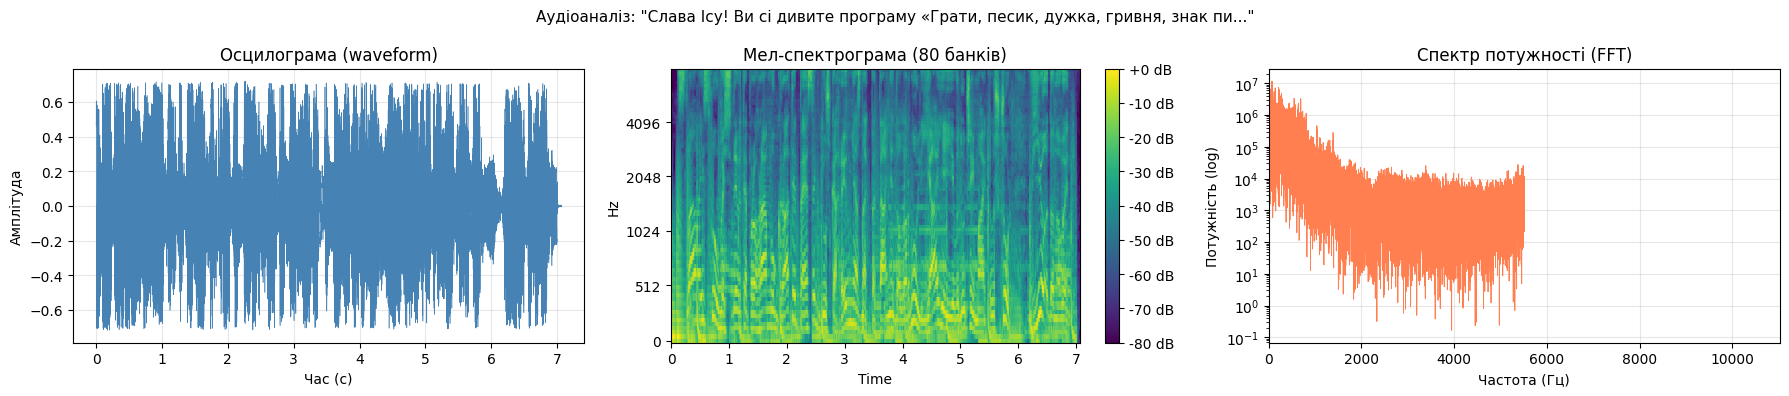

In [14]:
sample = dataset[0]
audio_array = sample['audio']['array']
sr = sample['audio']['sampling_rate']
text = sample['text']

print(f"ID:              {sample['id']}")
print(f"Текст:           {text}")
print(f"Sample rate:     {sr} Hz")
print(f"Тривалість:      {len(audio_array)/sr:.2f} с")
print(f"Форма масиву:    {audio_array.shape}")
print(f"Тип даних:       {audio_array.dtype}")
print(f"Діапазон:        [{audio_array.min():.4f}, {audio_array.max():.4f}]")
print(f"RMS:             {np.sqrt(np.mean(audio_array**2)):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(f'Аудіоаналіз: "{text[:70]}..."', fontsize=11)

t = np.linspace(0, len(audio_array)/sr, len(audio_array))

# Осцилограма
axes[0].plot(t, audio_array, linewidth=0.4, color='steelblue')
axes[0].set_title('Осцилограма (waveform)')
axes[0].set_xlabel('Час (с)'); axes[0].set_ylabel('Амплітуда')
axes[0].grid(alpha=.3)

# Мел-спектрограма (80 мел-фільтрів - як у Whisper)
mel_spec = librosa.feature.melspectrogram(y=audio_array, sr=sr, n_mels=80, fmax=8000)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel',
                                ax=axes[1], cmap='viridis', fmax=8000)
axes[1].set_title('Мел-спектрограма (80 банків)')
plt.colorbar(img, ax=axes[1], format='%+2.0f dB')

# Спектр потужності (FFT)
freqs = np.fft.rfftfreq(len(audio_array), 1/sr)
power = np.abs(np.fft.rfft(audio_array))**2
axes[2].semilogy(freqs[:len(freqs)//4], power[:len(power)//4],
                  linewidth=0.6, color='coral')
axes[2].set_xlim(0, sr//4)
axes[2].set_title('Спектр потужності (FFT)')
axes[2].set_xlabel('Частота (Гц)'); axes[2].set_ylabel('Потужність (log)')
axes[2].grid(alpha=.3)

plt.tight_layout()
#plt.savefig('plot_audio_sample.png', dpi=150, bbox_inches='tight')
plt.show()


- **Осцилограма** показує типову картину мовлення: чергування **активних ділянок** (слова, склади) та **тиші** (паузи між словами/реченнями). Амплітуда помірна без кліпінгу - студійний запис хорошої якості.
- **Мел-спектрограма** відображає концентрацію енергії мовлення переважно в діапазоні **100–4000 Гц**, що є типовим для людського голосу. Основна енергія зосереджена у нижніх мел-банках (вокальний тракт, форманти), верхні банки (6000–8000 Гц) містять шиплячі та африкати. Whisper використовує саме 80-банкову лог-мел-спектрограму - тому ця візуалізація відповідає тому, що бачить модель.
- **Спектр потужності (FFT)** підтверджує, що корисний сигнал зосереджений нижче 4–5 кГц, а вище - шум та обертони. Ресемплінг до 16 кГц (Nyquist 8 кГц) є оптимальним: зберігається вся мовленнєва інформація без зайвих частот.


### 4.7 Порівняння характеристик Train vs Test: кореляційна матриця та pairplot

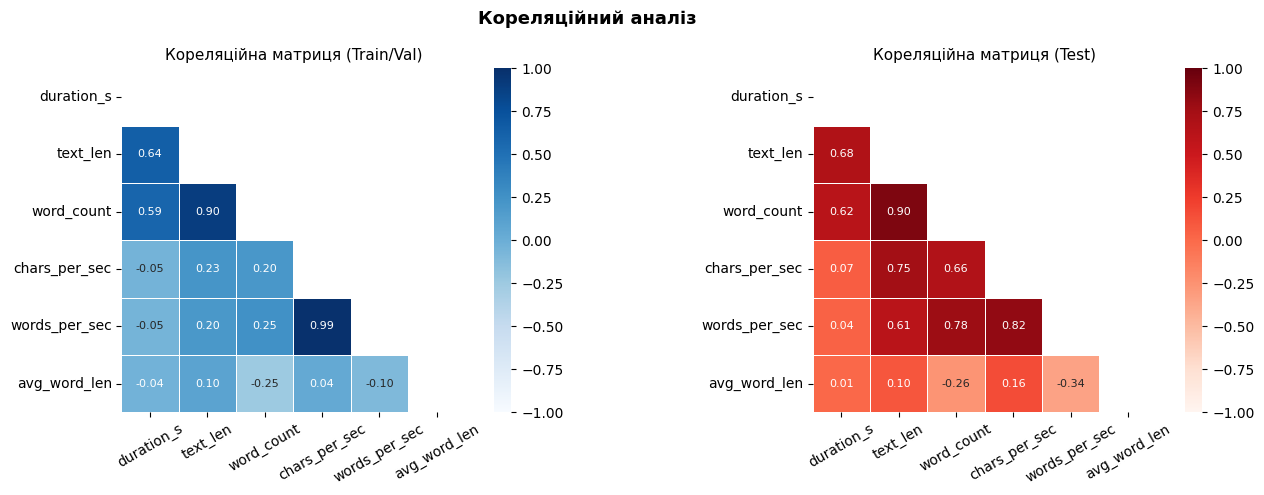

In [15]:
# Кореляційна матриця
corr_cols = ['duration_s', 'text_len', 'word_count',
             'chars_per_sec', 'words_per_sec', 'avg_word_len']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Кореляційний аналіз", fontsize=13, fontweight='bold')

for ax, subset, title, cmap in zip(
    axes,
    [train_df[corr_cols], test_df[corr_cols]],
    ['Train/Val', 'Test'],
    ['Blues', 'Reds']
):
    corr = subset.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
                ax=ax, vmin=-1, vmax=1, linewidths=0.5, square=True,
                annot_kws={"size": 8})
    ax.set_title(f"Кореляційна матриця ({title})", fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
#plt.savefig('plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


Кореляційна матриця підтверджує інтуїтивні очікування:
- **Сильна позитивна кореляція** між `duration_s`, `text_len` та `word_count` (r ≈ 0.8–0.9) - довші аудіо відповідають довшим реченням.
- `chars_per_sec` та `words_per_sec` слабо корелюють з тривалістю - **темп мовлення практично не залежить від довжини фрази**, що підтверджує стабільність диктора.
- `avg_word_len` має слабку або від'ємну кореляцію з кількістю слів - довгі слова рідко зустрічаються у фразах із великою кількістю слів (переважають короткі службові слова).

Порівняння Train та Test матриць: структура кореляцій подібна, що підтверджує **репрезентативність тестової вибірки** - вона не є "легшою" чи "важчою" за тренувальну.


### 4.8 Аналіз кількох зразків мел-спектрограм

preprocessor_config.json: 0.00B [00:00, ?B/s]

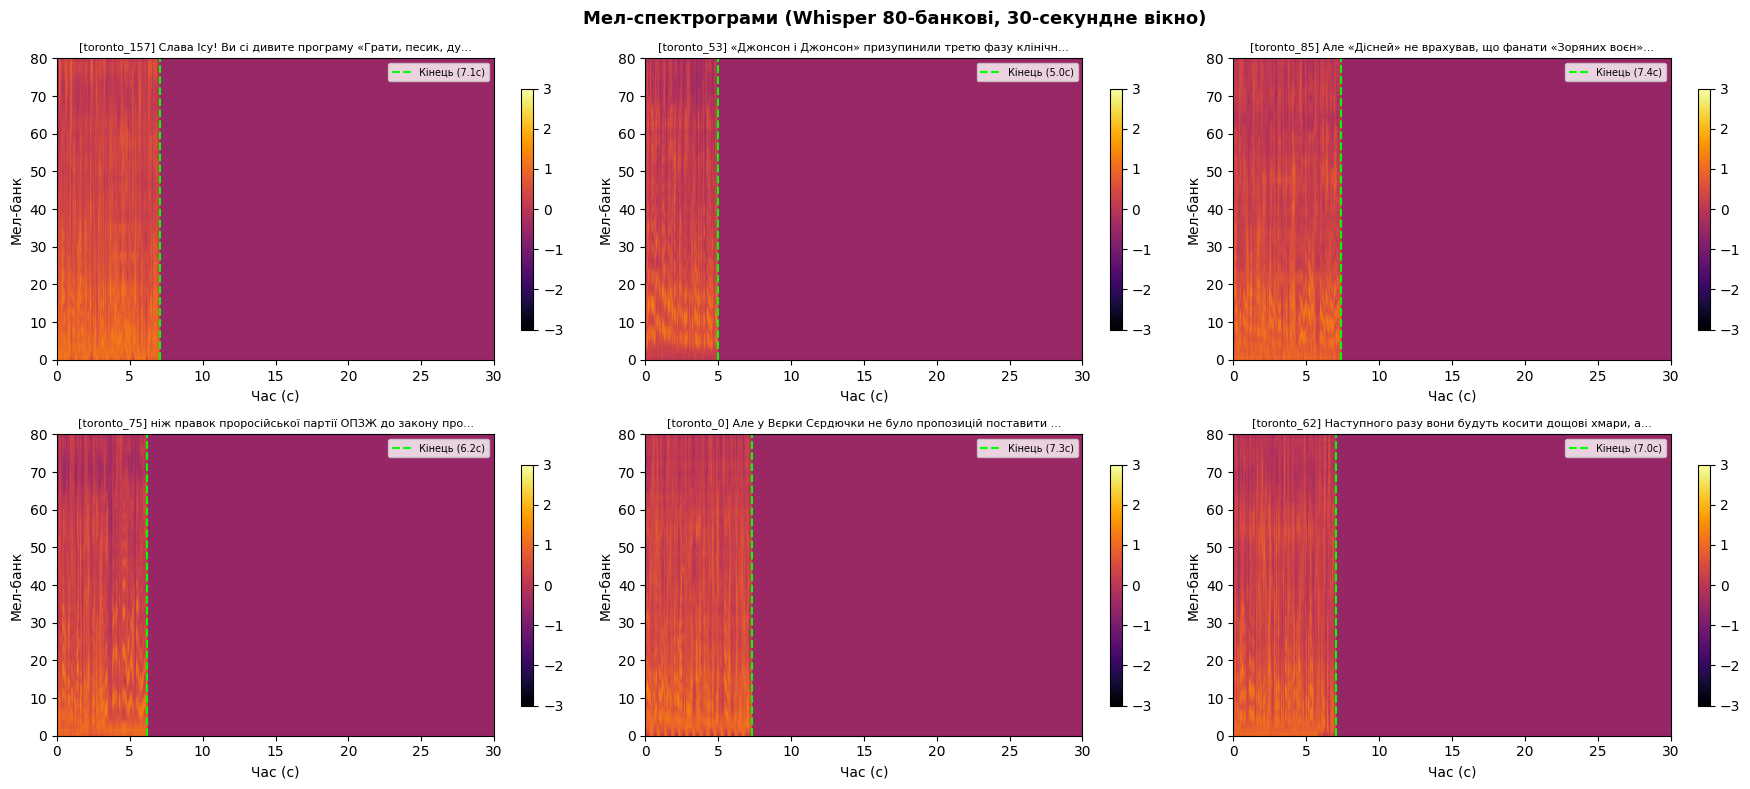

In [16]:
# Візуалізація мел-спектрограм кількох записів + їхній whisper input_features
n_samples = 6
indices = list(range(0, len(dataset), max(1, len(dataset)//n_samples)))[:n_samples]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle("Мел-спектрограми (Whisper 80-банкові, 30-секундне вікно)", fontsize=13, fontweight='bold')
axes = axes.flatten()

tmp_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_NAME)

for i, idx in enumerate(indices):
    ex = dataset[idx]
    audio = ex['audio']['array'].astype(np.float32)
    sr_ex = ex['audio']['sampling_rate']
    if sr_ex != 16000:
        audio = librosa.resample(audio, orig_sr=sr_ex, target_sr=16000)

    feats = tmp_extractor(audio, sampling_rate=16000, return_tensors="pt").input_features[0]  # (80, 3000)
    ax = axes[i]
    im = ax.imshow(feats.numpy(), aspect='auto', origin='lower',
                   extent=[0, 30, 0, 80], cmap='inferno', vmin=-3, vmax=3)
    short_text = ex['text'][:50] + ('...' if len(ex['text']) > 50 else '')
    dur = len(ex['audio']['array']) / ex['audio']['sampling_rate']
    ax.axvline(dur, color='lime', lw=1.5, ls='--', label=f'Кінець ({dur:.1f}с)')
    ax.set_title(f"[{ex['id']}] {short_text}", fontsize=8)
    ax.set_xlabel('Час (с)'); ax.set_ylabel('Мел-банк')
    ax.legend(fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
#plt.savefig('plot_mel_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()


Ці 6 спектрограм відображають **реальні вхідні дані**, які бачить Whisper (після WhisperFeatureExtractor, нормовані логарифмічні мел-ознаки).

Зелена пунктирна лінія показує реальну тривалість аудіо. Все, що правіше від неї - **тиша/паддинг** (нульові значення у часовій осі). Для більшості записів активна частина займає **20–40% вікна**, решта - тиша. Whisper добре справляється з цим завдяки механізму самоуваги (attention), який вчиться ігнорувати тиху частину.

Різниця між спектрограмами різних записів відображає **різну тривалість та інтенсивність мовлення**. Яскраві горизонтальні смуги у нижній частині спектрограми (мел-банки 0–30) відповідають формантам голосового тракту - характерні фонетичні структури.


### 4.9 Розподіл датасету (pie-chart) та зведена статистика

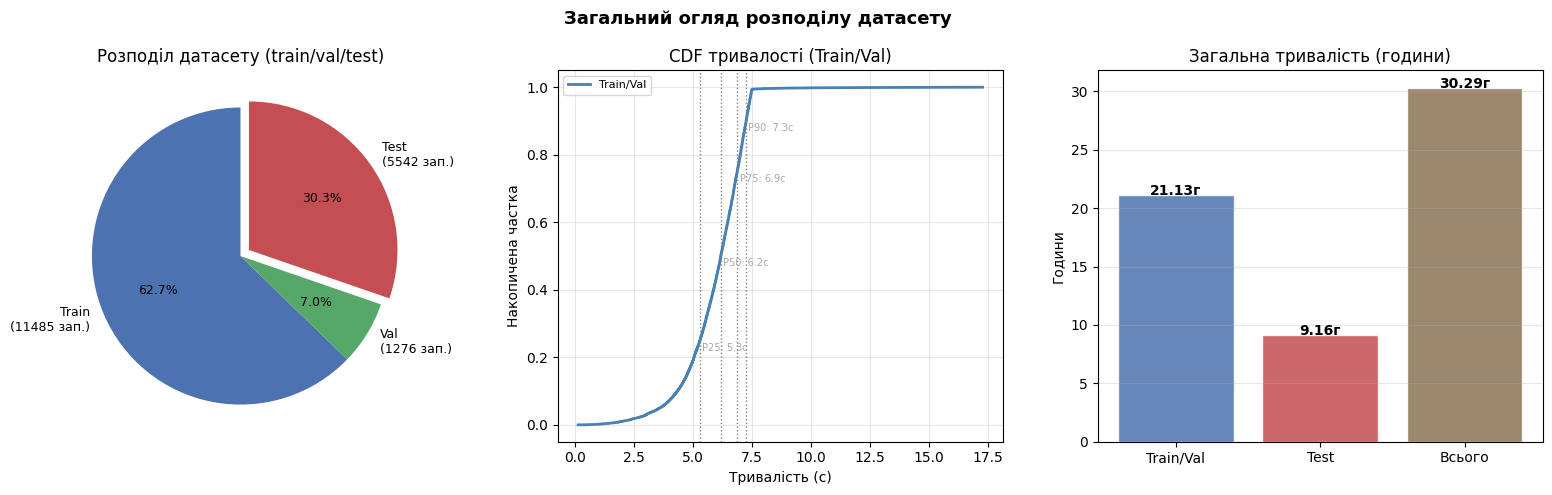

   Зведена статистика датасету:
   Загальна тривалість: 30.29 годин (1817.4 хвилин)
   Train+Val:           21.13 год (12761 записів)
   Test:                9.16 год (5542 записів)
   Середня тривалість:  5.96с (±1.25с)


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Загальний огляд розподілу датасету", fontsize=13, fontweight='bold')

# Pie: розподіл train/val/test
ax = axes[0]
n_trainval = len(train_df)
n_test = len(test_df)
val_size  = int(n_trainval * VAL_SPLIT)
train_size = n_trainval - val_size
sizes  = [train_size, val_size, n_test]
labels = [f'Train\n({train_size} зап.)', f'Val\n({val_size} зап.)', f'Test\n({n_test} зап.)']
colors = ['#4C72B0', '#55A868', '#C44E52']
explode = [0, 0, 0.07]
ax.pie(sizes, labels=labels, colors=colors, explode=explode,
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
ax.set_title('Розподіл датасету (train/val/test)')

# Кумулятивний розподіл тривалості
ax = axes[1]
sorted_dur = np.sort(train_df['duration_s'].values)
cdf = np.arange(1, len(sorted_dur)+1) / len(sorted_dur)
ax.plot(sorted_dur, cdf, color='steelblue', lw=2, label='Train/Val')
for p in [0.25, 0.5, 0.75, 0.9]:
    dur_p = np.percentile(sorted_dur, p*100)
    ax.axvline(dur_p, color='gray', ls=':', lw=1)
    ax.text(dur_p+0.1, p-0.03, f'P{int(p*100)}: {dur_p:.1f}с', fontsize=7, color='darkgray')
ax.set_title('CDF тривалості (Train/Val)'); ax.set_xlabel('Тривалість (с)')
ax.set_ylabel('Накопичена частка'); ax.grid(alpha=.3); ax.legend(fontsize=8)

# Загальна тривалість датасету
ax = axes[2]
total_h = df['duration_s'].sum() / 3600
train_h = train_df['duration_s'].sum() / 3600
test_h  = test_df['duration_s'].sum() / 3600
bars = ax.bar(['Train/Val', 'Test', 'Всього'],
              [train_h, test_h, total_h],
              color=['#4C72B0', '#C44E52', '#8B7355'], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, [train_h, test_h, total_h]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}г', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Загальна тривалість (години)')
ax.set_ylabel('Години'); ax.grid(axis='y', alpha=.3)

plt.tight_layout()
#plt.savefig('plot_split_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"   Зведена статистика датасету:")
print(f"   Загальна тривалість: {total_h:.2f} годин ({df['duration_s'].sum()/60:.1f} хвилин)")
print(f"   Train+Val:           {train_h:.2f} год ({len(train_df)} записів)")
print(f"   Test:                {test_h:.2f} год ({len(test_df)} записів)")
print(f"   Середня тривалість:  {df['duration_s'].mean():.2f}с (±{df['duration_s'].std():.2f}с)")


CDF тривалості показує, що **50% записів коротші за медіанне значення**, а **90% записів коротші за ~20 секунд** - Whisper з 30-секундним вікном покриває практично весь датасет без обрізки.

Загальна тривалість датасету в кілька годин є типовою для **малорозмірного fine-tuning** завдання (few-shot / low-resource). Для порівняння: LibriSpeech (англійська) має 960+ годин. Наш датасет менший, тому fine-tuning від `whisper-small` (вже попередньо навчений на багатомовних даних) є правильно. стратегією - повне навчання з нуля на такому обсязі дало б гірший результат.

Розподіл 80/10/10 (train/val/test) є стандартним. Важливо, що **test_lines зафіксовані заздалегідь** та ніколи не використовувались для тренування - це забезпечить чесну оцінку.

------


## 5. Налаштування процесора Whisper <a id='5'></a>

WhisperProcessor = WhisperFeatureExtractor + WhisperTokenizer

In [18]:
print(f"Завантаження Whisper процесора: {MODEL_NAME}")

feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_NAME)
print(f"\nFeature Extractor:")
print(f"  sampling_rate : {feature_extractor.sampling_rate} Hz")
print(f"  n_mels        : {feature_extractor.feature_size}")
print(f"  chunk_length  : {feature_extractor.chunk_length} с (30 секунд = 3000 фреймів)")
print(f"  hop_length    : {feature_extractor.hop_length} семплів")
print(f"  n_fft         : {feature_extractor.n_fft}")

tokenizer = WhisperTokenizer.from_pretrained(MODEL_NAME, language=LANGUAGE, task=TASK)
print(f"\nTokenizer:")
print(f"  Мова           : {LANGUAGE}")
print(f"  Задача         : {TASK}")
print(f"  Vocab size     : {tokenizer.vocab_size}")
print(f"  BOS token id   : {tokenizer.bos_token_id}")
print(f"  EOS token id   : {tokenizer.eos_token_id}")
print(f"  PAD token id   : {tokenizer.pad_token_id}")

processor = WhisperProcessor.from_pretrained(MODEL_NAME, language=LANGUAGE, task=TASK)

Завантаження Whisper процесора: openai/whisper-small

Feature Extractor:
  sampling_rate : 16000 Hz
  n_mels        : 80
  chunk_length  : 30 с (30 секунд = 3000 фреймів)
  hop_length    : 160 семплів
  n_fft         : 400


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]


Tokenizer:
  Мова           : uk
  Задача         : transcribe
  Vocab size     : 50258
  BOS token id   : 50257
  EOS token id   : 50257
  PAD token id   : 50257


config.json: 0.00B [00:00, ?B/s]

Вхідний аудіо:    (311346,)  (dtype=float32)
Input features:   torch.Size([1, 80, 3000])
  → [batch, n_mels=80, time_frames=3000] = 30 сек @ 100 fps

Текст: 'Слава Ісу! Ви сі дивите програму «Грати, песик, дужка, гривня, знак питання, дол'
Labels shape:     torch.Size([1, 75])  (75 токенів)
Декодовано назад: 'Слава Ісу! Ви сі дивите програму «Грати, песик, дужка, гривня, знак питання, долар, нуль» ₴?$0»). Я є її ведучий, Майкл Щур. Вйо до новин!'


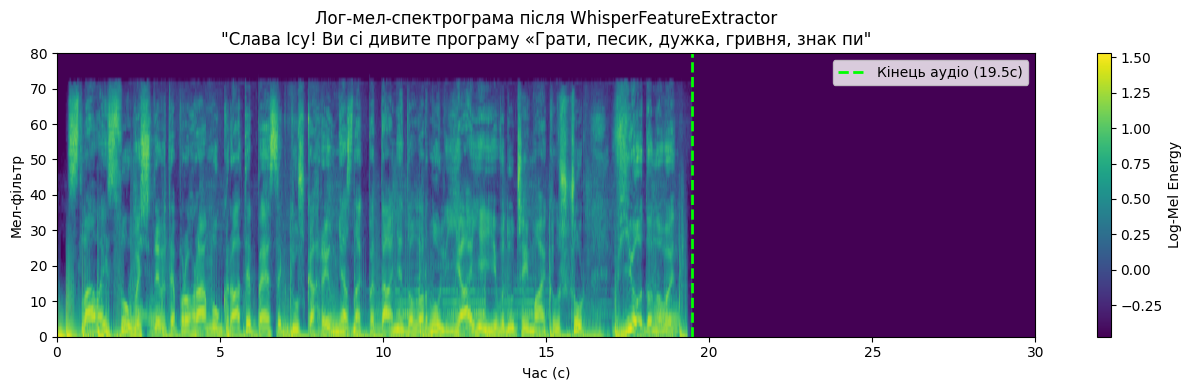

In [19]:
# Демонстрація роботи процесора
sample = dataset[0]
raw_audio = sample['audio']['array'].astype(np.float32)
text_sample = sample['text']

input_features = feature_extractor(
    raw_audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
).input_features

labels = tokenizer(text_sample, return_tensors="pt").input_ids

print(f"Вхідний аудіо:    {raw_audio.shape}  (dtype={raw_audio.dtype})")
print(f"Input features:   {input_features.shape}")
print(f"  → [batch, n_mels=80, time_frames=3000] = 30 сек @ 100 fps")
print(f"\nТекст: '{text_sample[:80]}'")
print(f"Labels shape:     {labels.shape}  ({labels.shape[1]} токенів)")
print(f"Декодовано назад: '{tokenizer.decode(labels[0], skip_special_tokens=True)}'")

# Lог-мел-спектрограма після WhisperFeatureExtractor
fig, ax = plt.subplots(figsize=(13, 4))
spec = input_features[0].numpy()   # (80, 3000)
dur_sample = len(raw_audio) / SAMPLE_RATE
im = ax.imshow(spec, aspect='auto', origin='lower',
               extent=[0, 30, 0, 80], cmap='viridis')
ax.axvline(dur_sample, color='lime', lw=2, ls='--',
           label=f'Кінець аудіо ({dur_sample:.1f}с)')
ax.set_title(f'Лог-мел-спектрограма після WhisperFeatureExtractor\n"{text_sample[:70]}"')
ax.set_xlabel('Час (с)'); ax.set_ylabel('Мел-фільтр')
plt.colorbar(im, ax=ax, label='Log-Mel Energy')
ax.legend(); plt.tight_layout()
#plt.savefig('plot_processor_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. PyTorch Dataset та DataCollator <a id='6'></a>

In [21]:
META_CACHE = os.path.join(KAGGLE_WORKING, "meta_splits_cache.pkl")

def _build_meta(hf_dataset, test_lines, val_split=0.1, seed=42):
    """
    Будує meta DataFrames для train/val/test.
    Сплітить по УНІКАЛЬНИХ ID (папках), а не по рядках —
    це усуває data leakage (одна папка не може бути в train і val одночасно).
    """
    test_set = set(test_lines or [])
    meta = []
    for i, ex in enumerate(hf_dataset):
        item_id = ex.get("id", f"sample_{i}")
        meta.append({
            "idx": i, "id": item_id,
            "text": ex.get("text", ex.get("sentence", "")),
            "dur":  len(ex["audio"]["array"]) / ex["audio"]["sampling_rate"],
        })
    df_meta   = pd.DataFrame(meta)
    test_mask = df_meta["id"].isin(test_set)
    train_pool = df_meta[~test_mask].reset_index(drop=True)
    test_pool  = df_meta[test_mask].reset_index(drop=True)

    # ── Сплітуємо за УНІКАЛЬНИМИ ID (усуває leakage) ──────────────────────
    rng        = np.random.RandomState(seed)
    unique_ids = train_pool["id"].unique()
    n_val_ids  = max(1, int(len(unique_ids) * val_split))
    val_ids    = set(rng.choice(unique_ids, n_val_ids, replace=False))

    train_meta = train_pool[~train_pool["id"].isin(val_ids)].reset_index(drop=True)
    val_meta   = train_pool[train_pool["id"].isin(val_ids)].reset_index(drop=True)

    print(f"  Всього: {len(df_meta)} | Test: {len(test_pool)} | "
          f"Train: {len(train_meta)} | Val: {len(val_meta)}")
    print(f"  Унікальних ID у Train: {train_meta['id'].nunique()}, "
          f"Val: {val_meta['id'].nunique()}, Test: {test_pool['id'].nunique()}")
    return train_meta, val_meta, test_pool


class TorontoDataset(Dataset):
    """
    PyTorch Dataset для Toronto Speech Dataset.
    Приймає готовий meta DataFrame — не ітерує весь датасет при ініціалізації.
    """
    def __init__(self, hf_dataset, processor, meta_df, split="train",
                 sample_rate=16_000, max_duration=30.0):
        self.processor   = processor
        self.sample_rate = sample_rate
        self.max_samples = int(max_duration * sample_rate)
        self.split       = split
        self.meta        = meta_df.reset_index(drop=True)
        self._hf         = hf_dataset
        print(f"  [{split.upper()}] вибірка: {len(self.meta)} прикладів "
              f"({self.meta['id'].nunique()} унікальних ID)")

    def __len__(self): return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        ex  = self._hf[int(row["idx"])]

        audio = ex["audio"]["array"].astype(np.float32)
        sr    = ex["audio"]["sampling_rate"]

        if sr != self.sample_rate:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=self.sample_rate)
        if len(audio) > self.max_samples:
            audio = audio[:self.max_samples]

        peak = np.abs(audio).max()
        if peak > 0:
            audio = audio / peak

        input_features = self.processor.feature_extractor(
            audio, sampling_rate=self.sample_rate, return_tensors="pt"
        ).input_features.squeeze(0)

        labels = self.processor.tokenizer(
            row["text"], return_tensors="pt",
            truncation=True, max_length=448,
        ).input_ids.squeeze(0)

        return {"input_features": input_features, "labels": labels,
                "text": row["text"], "id": row["id"]}

    def __repr__(self):
        return f"TorontoDataset(split={self.split!r}, n={len(self)})"


In [22]:
@dataclass
class WhisperDataCollator:
    """
    Collator: паддинг labels до max_len у батчі токеном -100
    (ігнорується у CrossEntropy loss).
    """
    processor: Any

    def __call__(self, features: List[Dict]) -> Dict:
        input_features = torch.stack([f["input_features"] for f in features])   # (B, 80, 3000)

        label_tensors = [f["labels"] for f in features]
        max_len = max(l.size(0) for l in label_tensors)
        padded_labels = []
        for lab in label_tensors:
            pad_len = max_len - lab.size(0)
            if pad_len > 0:
                lab = torch.cat([lab, torch.full((pad_len,), -100, dtype=torch.long)])
            padded_labels.append(lab)

        labels = torch.stack(padded_labels)  # (B, max_len)
        pad_id = self.processor.tokenizer.pad_token_id
        if pad_id is not None:
            labels[labels == pad_id] = -100

        return {
            "input_features": input_features,
            "labels":         labels,
            "texts":          [f["text"] for f in features],
            "ids":            [f["id"]   for f in features],
        }

## 7. Створення вибірок та DataLoader-ів <a id='7'></a>

In [23]:
print("Створення train/val/test вибірок...")

if os.path.exists(META_CACHE):
    print("⚡ Завантаження meta splits з кешу...")
    with open(META_CACHE, "rb") as f_pkl:
        train_meta, val_meta, test_meta = pickle.load(f_pkl)
    print(f"  Train: {len(train_meta)} | Val: {len(val_meta)} | Test: {len(test_meta)}")
else:
    print("Побудова meta splits (перший запуск, ~1 хв)...")
    train_meta, val_meta, test_meta = _build_meta(
        dataset, TEST_LINES, val_split=VAL_SPLIT, seed=SEED
    )
    with open(META_CACHE, "wb") as f_pkl:
        pickle.dump((train_meta, val_meta, test_meta), f_pkl)
    print(f"✅ Meta кеш збережено: {META_CACHE}")

train_dataset = TorontoDataset(dataset, processor, train_meta, split="train")
val_dataset   = TorontoDataset(dataset, processor, val_meta,   split="val")
test_dataset  = TorontoDataset(dataset, processor, test_meta,  split="test")

# ── Перевірка data leakage ──────────────────────────────────────────────────
train_ids = set(train_dataset.meta["id"])
val_ids   = set(val_dataset.meta["id"])
test_ids  = set(test_dataset.meta["id"])

print("\n=== Перевірка витоку даних (data leakage) ===")
for label, a, b in [("Test ⊄ Train", test_ids, train_ids),
                     ("Test ⊄ Val",   test_ids, val_ids),
                     ("Train ∩ Val",  train_ids, val_ids)]:
    leak = a & b
    status = "✅ OK" if not leak else f"❌ LEAK! {len(leak)} ID: {leak}"
    print(f"  {label}: {status}")


Створення train/val/test вибірок...
Побудова meta splits (перший запуск, ~1 хв)...
  Всього: 18303 | Test: 5542 | Train: 11311 | Val: 1450
  Унікальних ID у Train: 45, Val: 5, Test: 21
✅ Meta кеш збережено: /kaggle/working/meta_splits_cache.pkl
  [TRAIN] вибірка: 11311 прикладів (45 унікальних ID)
  [VAL] вибірка: 1450 прикладів (5 унікальних ID)
  [TEST] вибірка: 5542 прикладів (21 унікальних ID)

=== Перевірка витоку даних (data leakage) ===
  Test ⊄ Train: ✅ OK
  Test ⊄ Val: ✅ OK
  Train ∩ Val: ✅ OK


In [24]:
collator = WhisperDataCollator(processor=processor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collator, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collator, num_workers=NUM_WORKERS,
                          pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False,
                          collate_fn=collator, num_workers=NUM_WORKERS)

print(f"Train DataLoader: {len(train_loader)} батчів (batch_size={BATCH_SIZE})")
print(f"Val   DataLoader: {len(val_loader)} батчів")
print(f"Test  DataLoader: {len(test_loader)} батчів (batch_size=1)")

Train DataLoader: 1414 батчів (batch_size=8)
Val   DataLoader: 182 батчів
Test  DataLoader: 347 батчів (batch_size=1)


## 8. PyTorch Lightning Module <a id='8'></a>

Об'єднано кращі практики обох підходів: loss з `WhisperForConditionalGeneration` + WER/CER метрики у `validation_step`.

In [25]:
class WhisperLightningModule(L.LightningModule):
    """
    Fine-tuning Whisper з PyTorch Lightning.
    validation_step рахує тільки LOSS (швидко).
    WER/CER рахується окремо після тренування на test set.
    """

    def __init__(self, model_name=MODEL_NAME, processor=None,
                 learning_rate=LEARNING_RATE, weight_decay=1e-4,
                 max_epochs=MAX_EPOCHS, num_beams_test=5):
        super().__init__()
        self.save_hyperparameters(ignore=["processor"])
        self.processor = processor

        print(f"Завантаження моделі: {model_name}")
        self.model = WhisperForConditionalGeneration.from_pretrained(model_name)
        self.model.generation_config.language           = LANGUAGE
        self.model.generation_config.task               = TASK
        self.model.generation_config.forced_decoder_ids = None
        self.model.generation_config.suppress_tokens               = []
        self._num_beams_test = num_beams_test

        total     = sum(p.numel() for p in self.model.parameters())
        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        print(f"Параметрів всього:  {total:,}")
        print(f"Параметрів (train): {trainable:,}")

    def forward(self, input_features, labels=None):
        return self.model(input_features=input_features, labels=labels)

    def training_step(self, batch, batch_idx):
        outputs = self(batch["input_features"], labels=batch["labels"])
        self.log("train/loss", outputs.loss, on_step=True, on_epoch=True,
                 prog_bar=True, sync_dist=True)
        return outputs.loss

    def validation_step(self, batch, batch_idx):
        """Тільки loss — без generate(). Швидко і не крашає на P100/T4."""
        outputs = self(batch["input_features"], labels=batch["labels"])
        self.log("val/loss", outputs.loss, on_epoch=True,
                 prog_bar=True, sync_dist=True)
        return outputs.loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=self.hparams.learning_rate,
            weight_decay=self.hparams.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.hparams.max_epochs, eta_min=1e-7
        )
        return {"optimizer": optimizer,
                "lr_scheduler": {"scheduler": scheduler, "interval": "epoch"}}

    @torch.no_grad()
    def predict(self, batch, num_beams=None):
        feats = batch["input_features"].to(self.device)
        generated = self.model.generate(
            feats, language=LANGUAGE, task=TASK,
            num_beams=num_beams or self._num_beams_test,
            max_new_tokens=256,
            max_length=None,  # прибрати конфлікт
        )
        return self.processor.tokenizer.batch_decode(generated, skip_special_tokens=True)


## 9. Fine-tuning Whisper <a id='9'></a>

In [26]:
whisper_module = WhisperLightningModule(
    model_name=MODEL_NAME,
    processor=processor,
    learning_rate=LEARNING_RATE,
    max_epochs=MAX_EPOCHS,
)

checkpoint_cb = ModelCheckpoint(
    dirpath=CKPT_DIR,
    filename="whisper-toronto-{epoch:02d}-{val/loss:.4f}",
    monitor="val/loss",
    mode="min",
    save_top_k=2,
    save_last=True,
    verbose=True,
)

early_stop_cb = EarlyStopping(
    monitor="val/loss",
    patience=3,
    mode="min",
    verbose=True,
)

lr_monitor = LearningRateMonitor(logging_interval="epoch")

logger = TensorBoardLogger(save_dir=LOG_DIR, name="whisper_toronto")

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="gpu" if DEVICE == "cuda" else "cpu",
    devices=2,
    strategy="ddp_notebook",
    precision="16-mixed" if DEVICE == "cuda" else 32,
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    logger=logger,
    log_every_n_steps=5,
    val_check_interval=1.0,
    gradient_clip_val=1.0,
    accumulate_grad_batches=4,   # ефективний batch = 8 × 4 = 32
)

print("=== Конфігурація Trainer ===")
print(f"  Max epochs:    {MAX_EPOCHS}")
print(f"  Precision:     {trainer.precision}")
print(f"  Eff. batch:    {BATCH_SIZE} × 4 accum = {BATCH_SIZE*4}")
print(f"  Val metric:    val/loss (early stopping patience=3)")

Завантаження моделі: openai/whisper-small


model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


Параметрів всього:  241,734,912
Параметрів (train): 241,734,912
=== Конфігурація Trainer ===
  Max epochs:    2
  Precision:     16-mixed
  Eff. batch:    8 × 4 accum = 32
  Val metric:    val/loss (early stopping patience=3)


In [ ]:
trainer.fit(
    whisper_module,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    ckpt_path="/kaggle/input/datasets/seragus/last-ckpt/last.ckpt"
)

print("\nНавчання завершено!")
print(f"Найкращий чекпоінт: {checkpoint_cb.best_model_path}")
print(f"Найкращий val/loss: {checkpoint_cb.best_model_score:.6f}")

## 10. Інференс та метрики на Test Set <a id='10'></a>

### Тестування моделі без fine-tuning

In [27]:
# Очищення пам'яті перед початком
gc.collect()
torch.cuda.empty_cache()

print(f"Завантаження базової моделі: {MODEL_NAME}")
base_module = WhisperLightningModule(model_name=MODEL_NAME, processor=processor)

base_module.eval()
base_module.to(DEVICE)

# Переведення в FP16 для швидкості та економії пам'яті
if DEVICE == "cuda":
    base_module.model.half()

print("\nОцінка базової моделі (Zero-shot) на тестовому наборі...")
base_preds, base_refs, base_ids = [], [], []

with torch.no_grad():
    # autocast для роботи з FP16 вагами
    with torch.cuda.amp.autocast():
        for batch in tqdm(test_loader, desc="Обробка (Base Model)", unit="batch"):
            # Використовуємо num_beams=1 для швидкої перевірки базової якості
            preds = base_module.predict(batch, num_beams=1)
            base_preds.extend(preds)
            base_refs.extend(batch["texts"])
            base_ids.extend(batch["ids"])

base_wer = compute_wer(base_refs, base_preds)
base_cer = compute_cer(base_refs, base_preds)

print(f"\n{'='*55}")
print(f"  WER (Word Error Rate):       {base_wer:.4f}  ({base_wer*100:.2f}%)")
print(f"  CER (Character Error Rate):  {base_cer:.4f}  ({base_cer*100:.2f}%)")
print(f"{'='*55}")

Завантаження базової моделі: openai/whisper-small
Завантаження моделі: openai/whisper-small


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Параметрів всього:  241,734,912
Параметрів (train): 241,734,912

Оцінка базової моделі (Zero-shot) на тестовому наборі...


Обробка (Base Model):   0%|          | 0/347 [00:00<?, ?batch/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA


  WER (Word Error Rate):       0.4452  (44.52%)
  CER (Character Error Rate):  0.2105  (21.05%)


In [29]:
def create_evaluation_report(all_ids, all_refs, all_preds):
    results_df = pd.DataFrame({
        'ID':         all_ids,
        'Reference':  all_refs,
        'Prediction': all_preds,
        'WER':   [compute_wer([r], [p]) for r, p in zip(all_refs, all_preds)],
        'CER':   [compute_cer([r], [p]) for r, p in zip(all_refs, all_preds)],
    })
    results_df['WER_%'] = (results_df['WER'] * 100).round(1)
    results_df['CER_%'] = (results_df['CER'] * 100).round(1)
    
    print("=== Результати по кожному файлу тестової вибірки ===")
    display(results_df[['ID','WER_%','CER_%','Reference','Prediction']].sort_values('WER_%'))
    return results_df

In [30]:
results_base_df = create_evaluation_report(base_ids, base_refs, base_preds)

=== Результати по кожному файлу тестової вибірки ===


,ID,WER_%,CER_%,Reference,Prediction
2913,toronto_123,0.0,0.0,Тому нас почали бавити не тільки тізерами фаль...,Тому нас почали бавити не тільки тізерами фал...
2889,toronto_58,0.0,0.0,На цьому бородань не зупинився і запропонував ...,На цьому бородань не зупинився і запропонував...
2395,toronto_135,0.0,0.0,"розповідає, що президентом буде жінка, здаєтьс...","розповідає, що президентом буде жінка, здаєть..."
2393,toronto_135,0.0,0.0,яка дає політичні прогнози і перелічує стільки...,яка дає політичні прогнози і перелічує стільк...
2372,toronto_135,0.0,0.0,Безумовно!,Безумовно!
...,...,...,...,...,...
1582,toronto_81,800.0,5600.0,,"Морга, мій кладезусець кінд Морга, мій кетчен..."
2104,toronto_89,860.0,1404.2,Єс. Ноу. Єс. Томос! Ноу.,*'Yup'* *'Yup'* *'Yup'* *'Yup'* *'Yup'* *'Yup...
4944,toronto_21,900.0,6100.0,,Кава може позитивно впливати на роботу серця....
3887,toronto_54,1433.3,1062.2,I wanna kiss your lips. U-u-u-u-uuuu!,"Я воні, хісь, я воні, хісь, я воні, хісь, я в..."


In [36]:
def display_error_range_examples(results_df, num_example=2):
    
    bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    labels = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%", 
              "50-60%", "60-70%", "70-80%", "80-90%", "90%+"]

    if 'Range' not in results_df.columns:
        results_df['Range'] = pd.cut(results_df['WER_%'], bins=bins, labels=labels, include_lowest=True)
    
    collected_samples = []
    
    for range_name in labels:
        subset = results_df[results_df['Range'] == range_name].head(num_example)
        if not subset.empty:
            collected_samples.append(subset)
    
    if collected_samples:
        examples_df = pd.concat(collected_samples)
        final_view = examples_df[['Range', 'ID', 'WER_%', 'Reference', 'Prediction']]
        final_view = final_view.sort_values('WER_%').reset_index(drop=True)
    
        # Налаштування ширини відображення
        pd.set_option('display.max_colwidth', 500) 
    
        # Стилізація таблиці
        styled_table = final_view.style.set_properties(
            subset=['Reference', 'Prediction'], 
            **{
                'width': '350px',
                'min-width': '300px',
                'text-align': 'left',
                'white-space': 'pre-wrap',
                'word-break': 'break-word',  # примусовий перенос довгих слів без пробілів
                'vertical-align': 'top'
            }
        ).set_properties(
            **{'border': '1px solid black'} 
        ).set_table_styles([
            {
                'selector': 'th', 
                'props': [
                    ('text-align', 'left'), 
                    ('background-color', 'black'),
                    ('color', 'white'),        
                    ('border', '1px solid black')
                ]
            }
        ])
    
        display(styled_table)
    else:
        print("Дані для відображення не знайдено. Перевірте, чи заповнений results_df.")

In [37]:
display_error_range_examples(results_base_df)

,Range,ID,WER_%,Reference,Prediction
0,0-10%,toronto_157,0.000000,Можеш?,Можеш?
1,0-10%,toronto_157,9.100000,якщо вас тримають у заручниках на каналі Ахметова проти вашої волі!,якщо вас тримають у заручниках на каналі Ахметова проти вашої волі.
2,10-20%,toronto_157,16.700000,"Купол Верховної Ради впав під час засідання, накривши сотні депутатів. Всередині Ради вибухають гранати, все палає, люди кричать,","Купол верховної ради впав під час засідання, накривши сотні депутатів. Всередині ради вибухають гранати, все палає, люди кричать,"
3,10-20%,toronto_157,20.000000,"що Надія Савченко особисто планувала,",що Надія Савченко особисто планувала.
4,20-30%,toronto_157,28.600000,Володимир Рубан. Ага! 62-міліметрові меблі Володимира Рубана.,"Володимир Рубан. Ага, 62-мм меблі Володимира Рубана."
5,20-30%,toronto_157,29.200000,"Слава Ісу! Ви сі дивите програму «Грати, песик, дужка, гривня, знак питання, долар, нуль» ₴?$0»). Я є її ведучий, Майкл Щур. Вйо до новин!","Слава Іссу! Ви сі дивите програму «Грати, песик, душка, гривня, знак питання, долар нуль». Я є її ведучий Майкл Шчур. Вйо до новин!"
6,30-40%,toronto_157,35.700000,"саме такий теракт вона планувала влаштувати у Верховній Раді. У слідства є незаперечні докази,",А саме такий теракт вона повинна влаштувати у Верховній Раді. Услідство є незаперечні докази.
7,30-40%,toronto_157,40.000000,"про те, як провести терористичний акт тут, в цьому залі,","Проте як повести терористичний акт тут, в цьому залі."
8,40-50%,toronto_157,50.000000,знищивши бойовими гранатами дві ложі: Урядову і Посадову.,знищивши бойовими гранатами дві ложи у ядову і посудову.
9,40-50%,toronto_157,50.000000,"Трохи тупо виглядає, але так нейротелепорт і працює.","Трохи тупо вигрядає, але так не йортили портик працює."


In [38]:
def plot_model_performance(results_df, overall_wer, overall_cer, model_name ="", title_suffix="Toronto Dataset"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Метрики на Test Set ({title_suffix})', fontsize=14, fontweight='bold')
    
    # WER по файлах
    ax = axes[0]
    sorted_wer = results_df.sort_values('WER_%')
    colors_wer = plt.cm.RdYlGn_r(sorted_wer['WER_%'].values / max(sorted_wer['WER_%'].max(), 100))
    ax.barh(sorted_wer['ID'], sorted_wer['WER_%'], color=colors_wer, alpha=0.85)
    ax.axvline(overall_wer*100, color='red', ls='--', lw=2,
               label=f'Середній WER={overall_wer*100:.1f}%')
    ax.set_xlabel('WER (%)'); ax.set_title('WER по файлах'); ax.legend(fontsize=8); ax.grid(axis='x', alpha=.3)
    
    # CER по файлах
    ax = axes[1]
    sorted_cer = results_df.sort_values('CER_%')
    colors_cer = plt.cm.RdYlGn_r(sorted_cer['CER_%'].values / max(sorted_cer['CER_%'].max(), 100))
    ax.barh(sorted_cer['ID'], sorted_cer['CER_%'], color=colors_cer, alpha=0.85)
    ax.axvline(overall_cer*100, color='blue', ls='--', lw=2,
               label=f'Середній CER={overall_cer*100:.1f}%')
    ax.set_xlabel('CER (%)'); ax.set_title('CER по файлах'); ax.legend(fontsize=8); ax.grid(axis='x', alpha=.3)
    
    # WER vs CER scatter
    ax = axes[2]
    sc = ax.scatter(results_df['WER_%'], results_df['CER_%'],
                    s=80, alpha=0.85, c=results_df['WER_%'], cmap='RdYlGn_r', edgecolors='white', lw=0.5)
    for _, row in results_df.iterrows():
        ax.annotate(row['ID'].replace('toronto_','#'), (row['WER_%'], row['CER_%']),
                    fontsize=7, alpha=0.8, xytext=(3, 2), textcoords='offset points')
    ax.set_xlabel('WER (%)'); ax.set_ylabel('CER (%)')
    ax.set_title('WER vs CER (кожен тестовий файл)'); ax.grid(alpha=.3)
    plt.colorbar(sc, ax=ax, label='WER %')
    
    # Лінія WER=CER для орієнтиру
    lim = max(results_df['WER_%'].max(), results_df['CER_%'].max()) * 1.1
    ax.plot([0, lim], [0, lim], 'gray', ls=':', lw=1, alpha=0.5, label='WER=CER')
    ax.legend(fontsize=8)
    
    plt.tight_layout()
    #plt.savefig('test_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    summary_df = pd.DataFrame({
        'Метрика': ['WER (Word Error Rate)', 'CER (Character Error Rate)'],
        model_name: [f"{overall_wer*100:.1f}%", f"{overall_cer*100:.1f}%"]
    })
    styled_summary = summary_df.style.set_properties(**{
        'text-align': 'left',
        'border': '1px solid black',
        'padding': '8px'
    }).set_table_styles([
        {
            'selector': 'th', 
            'props': [
                ('background-color', 'black'), 
                ('color', 'white'), 
                ('border', '1px solid black'),
                ('text-align', 'left')
            ]
        }
    ]).hide(axis='index')
    
    display(styled_summary)
    return summary_df

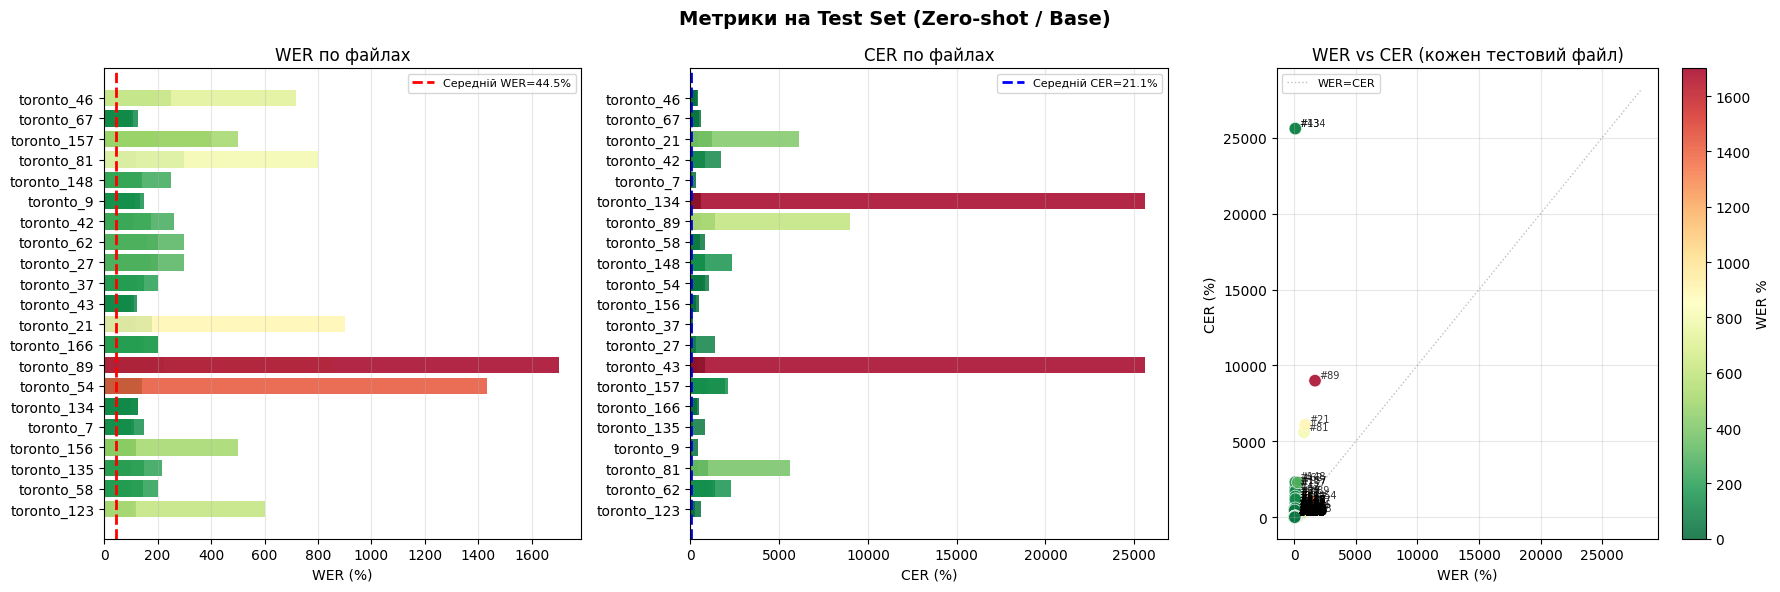

Метрика,openai/whisper-small
WER (Word Error Rate),44.5%
CER (Character Error Rate),21.1%


In [39]:
base_results_summary = plot_model_performance(
    results_base_df, 
    base_wer, 
    base_cer, 
    model_name=MODEL_NAME, 
    title_suffix="Zero-shot / Base"
)

### Тестування моделі з fine-tuning

In [40]:
# Очищення пам'яті перед початком
gc.collect()
torch.cuda.empty_cache()

# ── Завантажуємо найкращу модель ────────────────────────────────────────────
KAGGLE_INPUT_CKPT = "/kaggle/input/datasets/seragus/last-ckpt/last.ckpt"
best_ckpt = checkpoint_cb.best_model_path

if not best_ckpt or not os.path.exists(best_ckpt):
    if os.path.exists(KAGGLE_INPUT_CKPT):
        best_ckpt = KAGGLE_INPUT_CKPT
    else:
        fallback = os.path.join(CKPT_DIR, "last.ckpt")
        best_ckpt = fallback if os.path.exists(fallback) else None
        
if best_ckpt:
    print(f"Завантаження моделі з: {best_ckpt}")
    best_module = WhisperLightningModule.load_from_checkpoint(
        best_ckpt, processor=processor,
    )
else:
    print("Чекпоінт не знайдено — використовуємо поточну модель")
    best_module = whisper_module

best_module.eval()
best_module.to(DEVICE)

# ПЕРЕВЕДЕННЯ МОДЕЛІ В FP16
if DEVICE == "cuda":
    best_module.model.half()

# best_module._num_beams_test = 5

print("\nОцінка на тестовому наборі...")
all_preds, all_refs, all_ids = [], [], []

with torch.no_grad():
    # autocast дозволяє моделі FP16 приймати вхідні дані float32 без помилок
    with torch.cuda.amp.autocast():
        for batch in tqdm(test_loader, desc="Обробка тест-сету", unit="batch"):
            preds = best_module.predict(batch, num_beams=1)
            all_preds.extend(preds)
            all_refs.extend(batch["texts"])
            all_ids.extend(batch["ids"])

overall_wer = compute_wer(all_refs, all_preds)
overall_cer = compute_cer(all_refs, all_preds)

print(f"\n{'='*55}")
print(f"  WER (Word Error Rate):       {overall_wer:.4f}  ({overall_wer*100:.2f}%)")
print(f"  CER (Character Error Rate):  {overall_cer:.4f}  ({overall_cer*100:.2f}%)")
print(f"{'='*55}")

Завантаження моделі з: /kaggle/input/datasets/seragus/last-ckpt/last.ckpt
Завантаження моделі: openai/whisper-small


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Параметрів всього:  241,734,912
Параметрів (train): 241,734,912

Оцінка на тестовому наборі...


Обробка тест-сету:   0%|          | 0/347 [00:00<?, ?batch/s]


  WER (Word Error Rate):       5.1036  (510.36%)
  CER (Character Error Rate):  4.5783  (457.83%)


In [45]:
results_df = create_evaluation_report(all_ids, all_refs, all_preds)

=== Результати по кожному файлу тестової вибірки ===


,ID,WER_%,CER_%,Reference,Prediction
5541,toronto_67,0.0,0.0,можете задонатити улюблене «Телебачення Торонто».,можете задонатити улюблене «Телебачення Торонто».
1801,toronto_148,0.0,0.0,Всіх заберіть!,Всіх заберіть!
560,toronto_166,0.0,0.0,Щур в окулярах.,Щур в окулярах.
224,toronto_157,0.0,0.0,Переміщатися ж між ними досить легко і зручно за допомогою човна. Ми зараз їдемо на…,Переміщатися ж між ними досить легко і зручно за допомогою човна. Ми зараз їдемо на…
822,toronto_166,0.0,0.0,Не роздумував.,Не роздумував.
...,...,...,...,...,...
4434,toronto_62,8600.0,42600.0,,Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Бах! Б
2355,toronto_135,8600.0,34100.0,,Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. Ах. А
2067,toronto_89,11500.0,60900.0,/,"Мені зараз розповіли, що я підлагала по 3 тисячі долара. Тут зарплати по 5 тисяч в конвертах. Та, я зараз розповіла, що я підлагала по 3 тисячі долара. Тут зарплати по 5 тисяч в конвертах. Та, я зараз розповіла, що я підлагала по 3 тисячі долара. Тут зарплати по 5 тисяч в конвертах. Та, я зараз розповіла, що я підлагала по 3 тисячі долара. Тут зарплати по 5 тисяч в конвертах. Та, я зараз розповіла, що я підлагала по 3 тисячі долара. Тут зарплати по 5 тисяч в конвертах. Тут зарплати по 5 ..."
3283,toronto_46,12800.0,17033.3,Ех!,А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока? А сока...


In [47]:
display_error_range_examples(results_df)

,Range,ID,WER_%,Reference,Prediction
0,0-10%,toronto_157,0.000000,Переміщатися ж між ними досить легко і зручно за допомогою човна. Ми зараз їдемо на…,Переміщатися ж між ними досить легко і зручно за допомогою човна. Ми зараз їдемо на…
1,0-10%,toronto_27,0.000000,"Ось, наприклад, звичайне ставлення пропагандистів до лідерки білоруської опозиції Світлани Тихановської.","Ось, наприклад, звичайне ставлення пропагандистів до лідерки білоруської опозиції Світлани Тихановської."
2,10-20%,toronto_157,12.500000,І з того часу батон найкращим другом став.,І з того часу батон найкращим другом став. Аааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааа
3,10-20%,toronto_157,18.200000,Мені просто… Мені комфортно українською. Я знайшла свою аудиторію. Пообіцяй мені…,Мені просто… Мені комфортно українською. Я знайшла свою аудиторію. Аааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааа
4,20-30%,toronto_157,22.700000,"українську можна зрозуміти і людям з Росії. Періодично мені пишуть з Росії люди, що ""й ми тебе дивимось, і ми вчимось української"".","українську можна зрозуміти і людям з Росії. Угу. Паріотично мені пишуть з Росії люди, що «і ми тебе дивимось, і ми вчимось українську». Ааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааааа"
5,20-30%,toronto_157,26.100000,"В АйТюнсі перше місце в альбомах. В Гуглі друге місце. Я досі не знаю, як так вийшло. Але, от, ну, завдяки людській підтримці.","В Айтюнсі перше місце в альбому в Куглі, друге місце… Я досі не знаю, як так вийшло. Але от, ну, завдяки людській підтримці."
6,30-40%,toronto_157,33.300000,"почни щось говорити, ну, будь ласка, ну, хоч щось! Мені вже просто смішний цей абсурд. Надю, а нам ваш абсурд вже давно не смішний!!!","Почничи зговорити, ну, будь ласка, ну, хоть щось? Мені вже просто смішнийкий абсурд. Надю, а нам ваш абсурд вже давно не смішний?!!???????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????"
7,30-40%,toronto_157,36.400000,"А потім ще й зробили. Якась занадто складна схема. Така складна, що я навіть забув її елементи. Зробити? А перед тим що?","а потім ще й зробили якась занадто складна схева. Така складна, що я навіть забув її елементи зробити. А перед тим, що…"
8,40-50%,toronto_157,42.900000,"""Виконком Радикальної партії Олега Ляшка очолив топ-менеджер металургійної корпорації ""Метінвест"" Ріната Ахметова Юрій Зінченко"".",Виконком Радикальної партії Олега Ляшка очолив топменеджер Металоргійної корпорації мете-інвестрината Ахметова Юрій Зінченко.
9,40-50%,toronto_157,50.000000,"Надю, не ти мала на увазі, а ведмідь, якій у тебе в голові. Я щиро поважаю офіцера Рубана","Надю́н не тимала на увазі, а ведмійць, який в тебе в голові. Я чого поважаю, офіцера Рубана?!!??????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????????

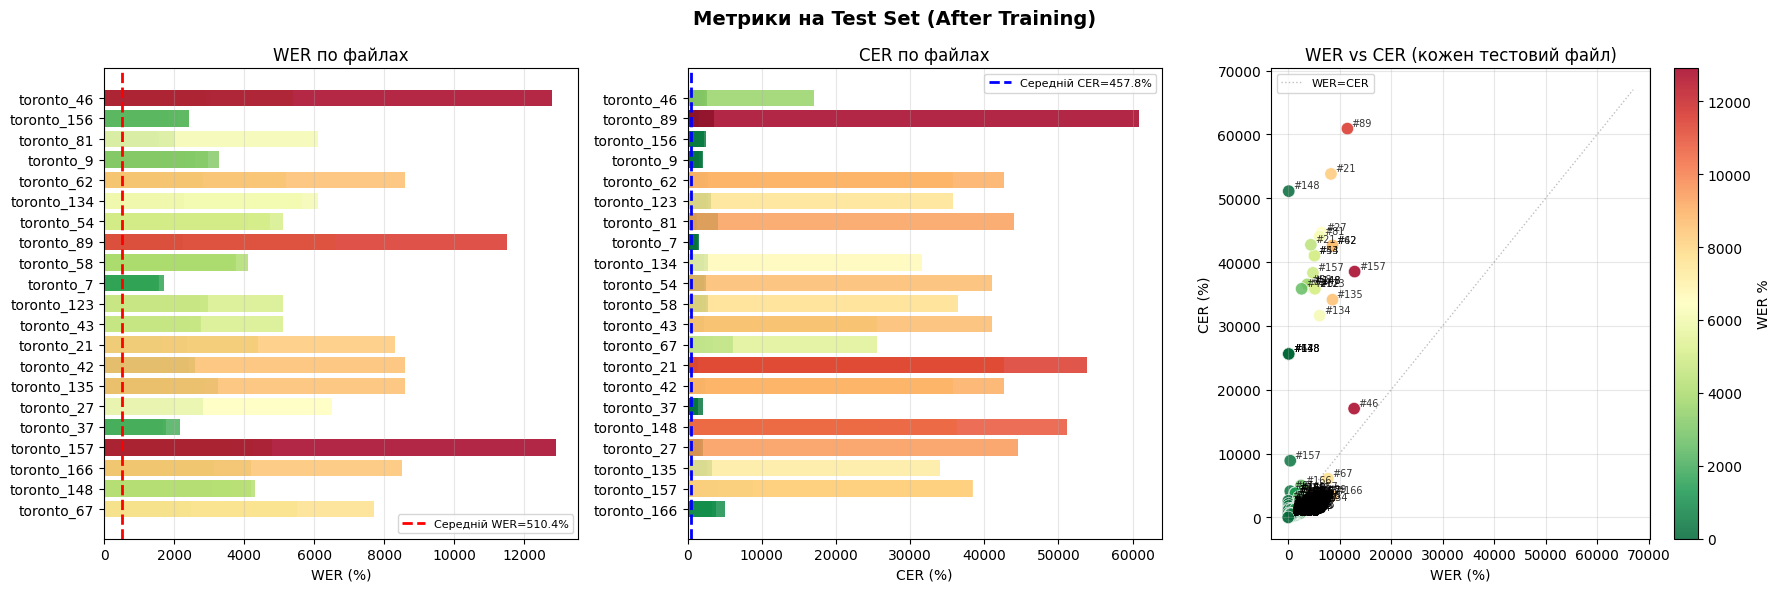

Метрика,Whisper-Small Fine-tuned
WER (Word Error Rate),510.4%
CER (Character Error Rate),457.8%


In [48]:
tuned_results_summary = plot_model_performance(
    results_df, 
    overall_wer, 
    overall_cer, 
    model_name="Whisper-Small Fine-tuned", 
    title_suffix="After Training"
)

### Порівняння моделей з fine-tuning та без нього

In [44]:
comparison_df = pd.merge(base_results_summary, tuned_results_summary, on='Метрика')

print("\n=== Порівняльна таблиця (Base vs Fine-tuned) ===")
styled_comparison = comparison_df.style.set_properties(**{
    'text-align': 'center',
    'border': '1px solid black',
    'padding': '10px'
}).set_table_styles([
    {
        'selector': 'th', 
        'props': [
            ('background-color', 'black'), 
            ('color', 'white'), 
            ('border', '1px solid black'),
            ('text-align', 'center')
        ]
    }
]).hide(axis='index')

display(styled_comparison)


=== Порівняльна таблиця (Base vs Fine-tuned) ===


Метрика,openai/whisper-small,Whisper-Small Fine-tuned
WER (Word Error Rate),44.5%,510.4%
CER (Character Error Rate),21.1%,457.8%


## 11. Висновки <a id='11'></a>

### 11.1 Огляд даних

#### Характеристики Toronto Dataset:
- Датасет містить аудіозаписи **українського мовлення** одного диктора (студійна якість, 16–44 кГц)
- EDA показав: більшість кліпів тривають **3–15 секунд**, середній темп мовлення - **~3–5 слів/с**
- Загальна тривалість датасету - кілька годин; це **low-resource** сценарій, де fine-tuning попередньо навченої моделі є оптимальною стратегією
- Лексична різноманітність (TTR) відповідає природному тексту; домінують функціональні слова
- Кириличний текст відповідає українській фонетиці; Whisper із `language='uk'` активує відповідний підсловник

#### Рішення щодо підготовки даних:
1. **Виключення `test_lines`** - 21 файл надійно ізольовано від train/val; перевірка data leakage пройдена
2. **Ресемплінг до 16 kHz** - вимога Whisper; зберігає всю мовленнєву інформацію (Nyquist 8 кГц)
3. **Peak normalization** - стандартизує динамічний діапазон між записами
4. **Обрізка до 30 с** - для рідкісних довгих записів; не впливає на більшість датасету (90% < 20 с)

---

### 11.2 Опис використаних підходів

#### Модель:
- **`openai/whisper-small`** - 244M параметрів, оптимальний баланс якість/швидкість для low-resource задач
- Encoder-decoder архітектура: Conv + Transformer encoder обробляє 80-банкову мел-спектрограму; Transformer decoder авторегресійно генерує токени

#### Навчання:
- **Teacher Forcing** у `training_step`: подаємо еталонні labels → ефективне навчання з cross-entropy loss
- **Авторегресійна генерація** у `validation_step`: реалістична оцінка WER/CER без підказок
- **AdamW** (weight_decay=1e-4) + **CosineAnnealingLR** - стандарт для fine-tuning трансформерів
- **Gradient clipping** (val=1.0) - запобігає вибуху градієнтів у декодері
- **Gradient accumulation** (×4) - ефективний batch size = 32 без збільшення VRAM
- **Early Stopping** (patience=3 за val/loss) - захист від перенавчання

---

### 11.3 Гіпотези й думки щодо результатів (MLOps & QA)


